<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana3/RegresionLogistica2Clases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)


datos = load_breast_cancer(as_frame=True)

X = datos.data
y = (datos.target == 0).astype(int)

In [3]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


(array([357.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 212.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

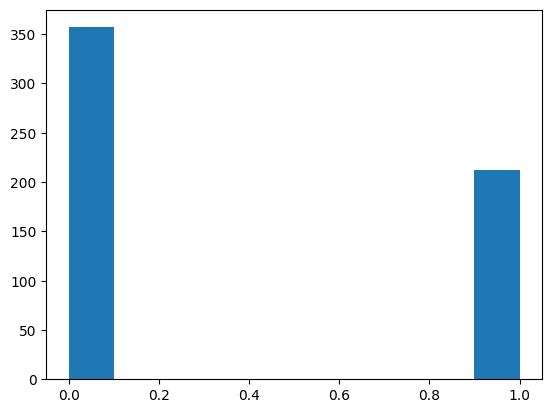

In [6]:
# Clases no balanceadas
plt.hist(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
X_train.shape

(455, 30)

In [9]:
X_test.shape

(114, 30)

In [11]:
# Crear un pipeline completo
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver='lbfgs',
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

In [14]:
# Porque estandarizamos
# Un paso muy importante
# z = (x - media )/desviacion

# Luego aplicamos la regresión

# Problema:
# Primero estandarizamos y luego dividimos el set?
# Un problema de fuga de información - leakage

In [15]:
# Validacion cruzada - k-folds validation
# Stratied porque tenemos desbalance
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [16]:
resultados_cv = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

In [19]:
for metrica in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]:
    desviacion = resultados_cv[metrica].std()
    print(f"{metrica}: {resultados_cv[metrica].mean():.3f}")
    print(f"{desviacion}:")

test_accuracy: 0.974
0.014906219743132443:
test_precision: 0.977
0.027994168488950616:
test_recall: 0.953
0.03989605872426629:
test_f1: 0.964
0.020700447685741707:
test_roc_auc: 0.996
0.004665698474904977:


In [20]:
# Entrenar el modelo final
modelo.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000, random_state=42))])

In [21]:
 # Vamos a predecir
y_pred = modelo.predict(X_test)

In [22]:
# Vamos a mirar la probabilidad de pertenencia
y_prob = modelo.predict_proba(X_test)[:,1]
y_prob

array([3.64568116e-04, 9.99999989e-01, 4.25679471e-02, 5.76187322e-01,
       5.09155489e-01, 6.16001620e-04, 7.61534086e-01, 1.01217174e-03,
       5.68725516e-04, 1.07675795e-02, 9.30905953e-01, 7.28319772e-05,
       9.99999899e-01, 4.39449272e-03, 7.75262630e-03, 1.70641370e-06,
       6.14294329e-02, 3.62811536e-04, 2.21762013e-01, 5.07279789e-05,
       1.26622816e-03, 4.30342121e-03, 9.99999581e-01, 9.98321524e-01,
       7.57606906e-01, 2.05880632e-04, 1.68680282e-04, 9.69171419e-01,
       9.96639529e-01, 9.99579644e-01, 9.99991854e-01, 2.37027672e-03,
       9.99964222e-01, 9.99954679e-01, 2.66371788e-04, 1.39030746e-02,
       2.02020415e-03, 3.20211147e-06, 9.90930715e-01, 9.31932725e-02,
       1.25745605e-04, 3.52528144e-04, 8.52325081e-01, 2.51409506e-03,
       1.08172442e-02, 9.54067888e-01, 7.56926419e-02, 9.98508631e-01,
       5.69898683e-05, 1.11541174e-03, 9.99999992e-01, 9.98457814e-01,
       7.12763094e-03, 1.05057651e-03, 1.21417298e-04, 9.88025845e-01,
      